In [5]:
import optuna
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from utils import integrated_brier_score, kaplan_meier, uno_c_index_rmst
from km_gg import GG_KM
# from km_gg_bn import GG_KM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

In [6]:
## optuna otimiza com ibs

def cross_validate_gg_km(
    X,
    t,
    delta,
    kernel="rbf",
    n_outer_splits=5,
    n_inner_splits=4,
    n_trials=50,
    t_grid_points=50,
    random_state=42,
):

    outer_cv = KFold(
        n_splits=n_outer_splits,
        shuffle=True,
        random_state=random_state
    )

    all_test_ibs = []
    all_test_cindex = []
    all_best_params = []

    print(f"{'='*60}")
    print(
        f" Nested CV: {n_outer_splits} outer × {n_inner_splits} inner folds"
    )
    print(f" Kernel: {kernel}")
    print(f" Optuna trials per fold: {n_trials}")
    print(f"{'='*60}\n")

    for fold_idx, (train_idx, test_idx) in enumerate(
        outer_cv.split(X)
    ):

        print(
            f"─── Outer fold {fold_idx + 1}/{n_outer_splits} ",
            end="",
            flush=True
        )

        X_outer_train, X_test = (
            X[train_idx],
            X[test_idx]
        )

        t_outer_train, t_test = (
            t[train_idx],
            t[test_idx]
        )

        d_outer_train, d_test = (
            delta[train_idx],
            delta[test_idx]
        )

        t_lo = np.percentile(
            t_outer_train,
            5
        )

        t_hi = np.percentile(
            t_outer_train,
            95
        )

        t_grid = np.linspace(
            t_lo,
            t_hi,
            t_grid_points
        )

        inner_cv = KFold(
            n_splits=n_inner_splits,
            shuffle=True,
            random_state=random_state
        )

        def objective(trial):

            params = {
                "lambda_reg": trial.suggest_float(
                    "lambda_reg",
                    1e-5,
                    1.0,
                    log=True
                )
            }

            if kernel in {
                "rbf",
                "gaussian",
                "laplacian",
                "exponential",
                "cauchy",
                "sigmoid",
            }:

                params["gamma"] = trial.suggest_float(
                    "gamma",
                    1e-3,
                    10.0,
                    log=True
                )

            if kernel == "polynomial":

                params["gamma"] = trial.suggest_float(
                    "gamma",
                    1e-3,
                    10.0,
                    log=True
                )

                params["degree"] = trial.suggest_int(
                    "degree",
                    2,
                    6
                )

                params["coef0"] = trial.suggest_float(
                    "coef0",
                    0.0,
                    5.0
                )

            if kernel == "sigmoid":

                params["coef0"] = trial.suggest_float(
                    "coef0",
                    -5.0,
                    5.0
                )

            val_scores = []

            for tr_idx, val_idx in inner_cv.split(
                X_outer_train
            ):

                X_tr, X_val = (
                    X_outer_train[tr_idx],
                    X_outer_train[val_idx]
                )

                t_tr, t_val = (
                    t_outer_train[tr_idx],
                    t_outer_train[val_idx]
                )

                d_tr, d_val = (
                    d_outer_train[tr_idx],
                    d_outer_train[val_idx]
                )

                scaler = StandardScaler()

                X_tr_s = scaler.fit_transform(
                    X_tr
                )

                X_val_s = scaler.transform(
                    X_val
                )

                t_grid_inner = np.linspace(
                    np.percentile(t_tr, 5),
                    np.percentile(t_tr, 95),
                    t_grid_points
                )

                try:

                    model = GG_KM(
                        kernel=kernel,
                        **params
                    )

                    model.fit(
                        X_tr_s,
                        t_tr,
                        d_tr
                    )

                    S_pred = model.predict_survival(
                        X_val_s,
                        t_grid_inner
                    )

                    ibs = integrated_brier_score(
                        S_pred,
                        t_val,
                        d_val,
                        t_tr,
                        d_tr,
                        t_grid_inner
                    )

                    val_scores.append(
                        ibs
                    )

                except Exception:
                    return 1.0

            return float(
                np.mean(val_scores)
            )

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(
                seed=random_state
            ),
        )

        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=False
        )

        best_params = study.best_params

        print(
            f"→ best val IBS = {study.best_value:.4f}"
        )

        scaler = StandardScaler()

        X_outer_train_s = scaler.fit_transform(
            X_outer_train
        )

        X_test_s = scaler.transform(
            X_test
        )

        final_model = GG_KM(
            kernel=kernel,
            **best_params
        )

        final_model.fit(
            X_outer_train_s,
            t_outer_train,
            d_outer_train
        )

        S_test = final_model.predict_survival(
            X_test_s,
            t_grid
        )

        # -------------------------
        # IBS
        # -------------------------
        test_ibs = integrated_brier_score(
            S_test,
            t_test,
            d_test,
            t_outer_train,
            d_outer_train,
            t_grid
        )

        # -------------------------
        # Uno IPCW C-index
        # -------------------------
        test_cindex = uno_c_index_rmst(
            S_pred=S_test,
            t_eval=t_test,
            delta_eval=d_test,
            t_train=t_outer_train,
            delta_train=d_outer_train,
            t_grid=t_grid,
            tau=t_grid[-1]
        )

        print(
            f"           test IBS     = {test_ibs:.4f}"
        )

        print(
            f"           test C-index = {test_cindex:.4f}\n"
        )

        all_test_ibs.append(
            test_ibs
        )

        all_test_cindex.append(
            test_cindex
        )

        all_best_params.append(
            best_params
        )

    print(f"{'='*60}")
    print(" Cross-Validation Results")
    print(f"{'='*60}")

    print(
        f" IBS per fold     : "
        f"{[f'{v:.4f}' for v in all_test_ibs]}"
    )

    print(
        f" C-index per fold : "
        f"{[f'{v:.4f}' for v in all_test_cindex]}"
    )

    print(
        f" Mean IBS         : "
        f"{np.mean(all_test_ibs):.4f}"
    )

    print(
        f" Std IBS          : "
        f"{np.std(all_test_ibs):.4f}"
    )

    print(
        f" Mean C-index     : "
        f"{np.nanmean(all_test_cindex):.4f}"
    )

    print(
        f" Std C-index      : "
        f"{np.nanstd(all_test_cindex):.4f}"
    )

    print(f"{'='*60}\n")

    return {
        "test_ibs": all_test_ibs,
        "mean_ibs": float(
            np.mean(all_test_ibs)
        ),
        "std_ibs": float(
            np.std(all_test_ibs)
        ),
        "test_cindex": all_test_cindex,
        "mean_cindex": float(
            np.nanmean(all_test_cindex)
        ),
        "std_cindex": float(
            np.nanstd(all_test_cindex)
        ),
        "best_params": all_best_params,
    }


In [ ]:
melanoma = (
    pd.read_csv("../data/melanoma.csv")
    .assign(status=lambda x: (x.status == 1).astype(int))
    .fillna(0)
)

y = melanoma[["time", "status"]]

X_raw = melanoma.drop(columns=y.columns.tolist()).to_numpy()

t = y["time"].to_numpy().astype(float)
delta = y["status"].to_numpy().astype(float)

kernels = [
    "linear",
    "rbf",
    "laplacian",
    "exponential",
    "cauchy",
    "sigmoid",
    "polynomial",
]

all_results = {}

for kernel in kernels:

    print("\n")
    print("=" * 80)
    print(f"Kernel: {kernel}")
    print("=" * 80)

    results = cross_validate_gg_km(
        X_raw,
        t,
        delta,
        n_outer_splits=5,
        n_inner_splits=4,
        n_trials=20,
        t_grid_points=50,
        random_state=42,
        kernel=kernel,
    )

    all_results[kernel] = results

print("\n")
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

for kernel, res in all_results.items():
    print(
        f"{kernel:12s} "
        f"Mean IBS = {res['mean_ibs']:.4f} "
        f"± {res['std_ibs']:.4f}"
    )



Kernel: linear
 Nested CV: 5 outer × 4 inner folds
 Kernel: linear
 Optuna trials per fold: 20

─── Outer fold 1/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1845
           test IBS     = 0.1129
           test C-index = 0.6945

─── Outer fold 2/5 → best val IBS = 0.1436
           test IBS     = 0.1509
           test C-index = 0.6867

─── Outer fold 3/5 → best val IBS = 0.1715
           test IBS     = 0.1643
           test C-index = 0.7954

─── Outer fold 4/5 → best val IBS = 0.1540
           test IBS     = 0.1979
           test C-index = 0.6874

─── Outer fold 5/5 → best val IBS = 0.1682
           test IBS     = 0.1294
           test C-index = 0.6802

 Cross-Validation Results
 IBS per fold     : ['0.1129', '0.1509', '0.1643', '0.1979', '0.1294']
 C-index per fold : ['0.6945', '0.6867', '0.7954', '0.6874', '0.6802']
 Mean IBS         : 0.1511
 Std IBS          : 0.0293
 Mean C-index     : 0.7088
 Std C-index      : 0.0435



Kernel: rbf
 Nested CV: 5 outer × 4 inner folds
 Kernel: rbf
 Optuna trials per fold: 20

─── Outer fold 1/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1697
           test IBS     = 0.1190
           test C-index = 0.6663

─── Outer fold 2/5 

...

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1546
           test IBS     = 0.2001
           test C-index = 0.6965

─── Outer fold 5/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1681
           test IBS     = 0.1335
           test C-index = 0.6873

 Cross-Validation Results
 IBS per fold     : ['0.1190', '0.1512', '0.1743', '0.2001', '0.1335']
 C-index per fold : ['0.6663', '0.7166', '0.7874', '0.6965', '0.6873']
 Mean IBS         : 0.1556
 Std IBS          : 0.0289
 Mean C-index     : 0.7108
 Std C-index      : 0.0416



Kernel: laplacian
 Nested CV: 5 outer × 4 inner folds
 Kernel: laplacian
 Optuna trials per fold: 20

─── Outer fold 1/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

In [ ]:
pd.DataFrame(all_results).to_csv("experiment_results_em.csv",index=False)

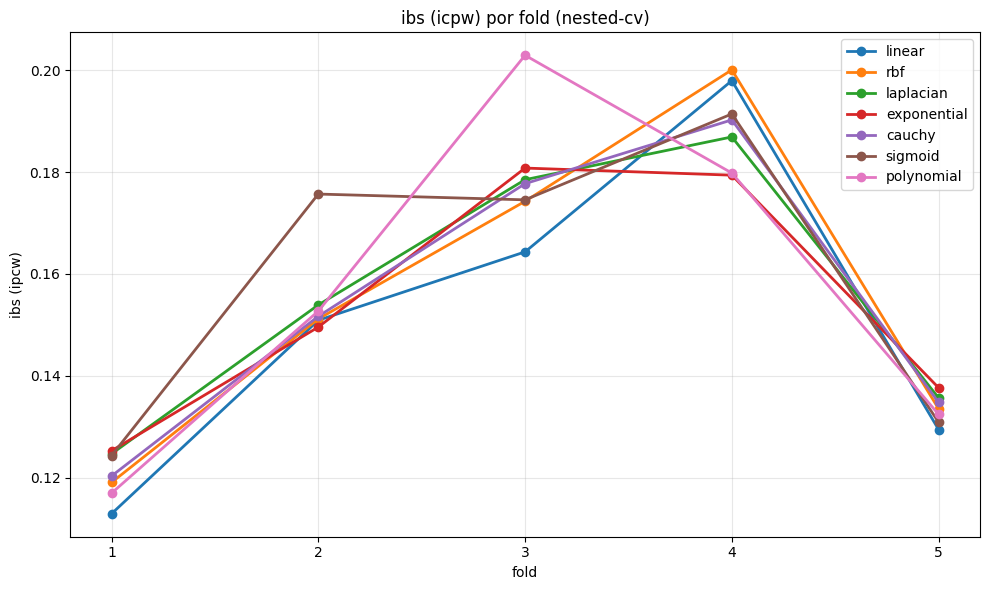

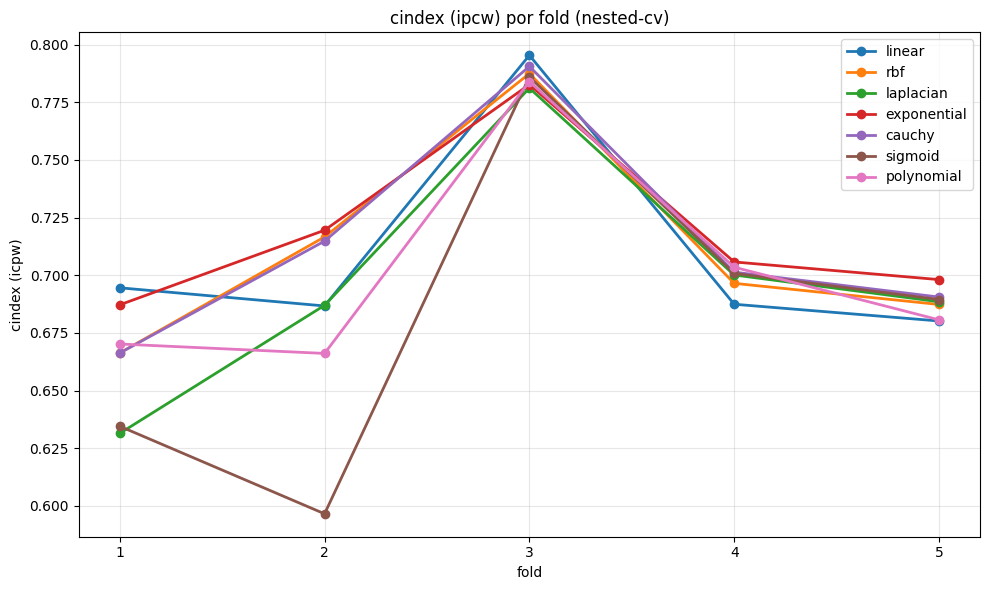

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

for kernel, res in all_results.items():

    ibs = np.asarray(res["test_ibs"])

    folds = np.arange(
        1,
        len(ibs) + 1
    )

    plt.plot(
        folds,
        ibs,
        marker="o",
        linewidth=2,
        label=kernel
    )

plt.xlabel("fold")
plt.ylabel("ibs (ipcw)")
plt.title("ibs (icpw) por fold (nested-cv)")
plt.xticks(folds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

for kernel, res in all_results.items():

    cindex = np.asarray(
        res["test_cindex"]
    )

    folds = np.arange(
        1,
        len(cindex) + 1
    )

    plt.plot(
        folds,
        cindex,
        marker="o",
        linewidth=2,
        label=kernel
    )

plt.xlabel("fold")
plt.ylabel("cindex (icpw)")
plt.title("cindex (ipcw) por fold (nested-cv)")
plt.xticks(folds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
import pandas as pd

summary_df = pd.DataFrame([
    {
        "kernel": kernel,
        "mean_ibs": res["mean_ibs"],
        "std_ibs": res["std_ibs"],
        "mean_cindex": res["mean_cindex"],
        "std_cindex": res["std_cindex"],
    }
    for kernel, res in all_results.items()
])

summary_df

,kernel,mean_ibs,std_ibs,mean_cindex,std_cindex
0,linear,0.151100,0.029321,0.708832,0.043503
1,rbf,0.155606,0.028877,0.710821,0.041578
2,laplacian,0.155920,0.023922,0.697620,0.048079
3,exponential,0.154526,0.022239,0.718637,0.033706
4,cauchy,0.154939,0.026009,0.712691,0.042044
5,sigmoid,0.159364,0.026695,0.681460,0.064446
6,polynomial,0.156956,0.031165,0.700869,0.043517


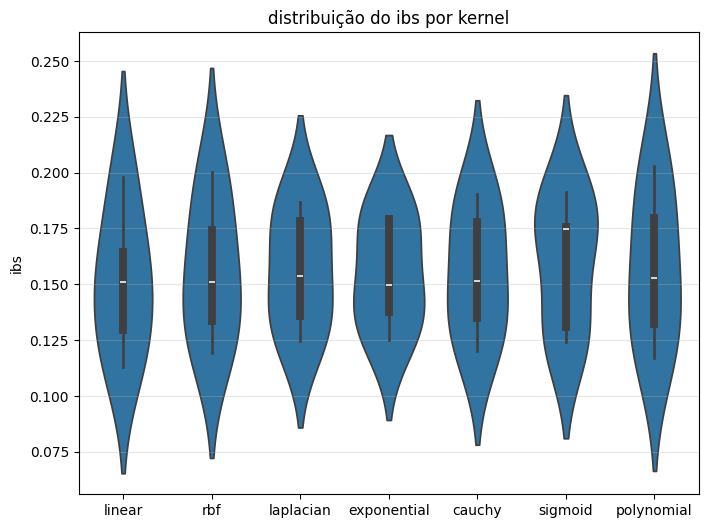

In [ ]:
import pandas as pd

data = []

for kernel, res in all_results.items():

    for ibs in res["test_ibs"]:

        data.append({
            "kernel": kernel,
            "test_ibs": ibs
        })

df_plot = pd.DataFrame(data)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df_plot,
    x="kernel",
    y="test_ibs",
    inner="box"
)

plt.xlabel("")
plt.ylabel("ibs")
plt.title("distribuição do ibs por kernel")
plt.grid(axis="y", alpha=0.3)

plt.show()

# all_results = pd.read_csv("melanoma_results_em_bn.csv")
# data = []

# for kernel, results in all_results.items():
#     for ibs in eval(results[0]):
#         data.append({
#             "kernel": kernel,
#             "test_ibs": ibs
#         })

# df_plot = pd.DataFrame(data)

# plt.figure(figsize=(8, 6))

# sns.violinplot(
#     data=df_plot,
#     x="kernel",
#     y="test_ibs",
#     inner="box"
# )

# plt.xlabel("")
# plt.ylabel("IBS")
# plt.title("Distribuição do IBS por Kernel")
# plt.grid(axis="y", alpha=0.3)

# plt.show()

In [33]:
df_plot_cindex

,kernel,test_cindex
0,linear,0.694545
1,linear,0.686675
2,linear,0.795359
3,linear,0.687418
4,linear,0.680160
5,rbf,0.666275
6,rbf,0.716604
7,rbf,0.787424
8,rbf,0.696484
9,rbf,0.687316


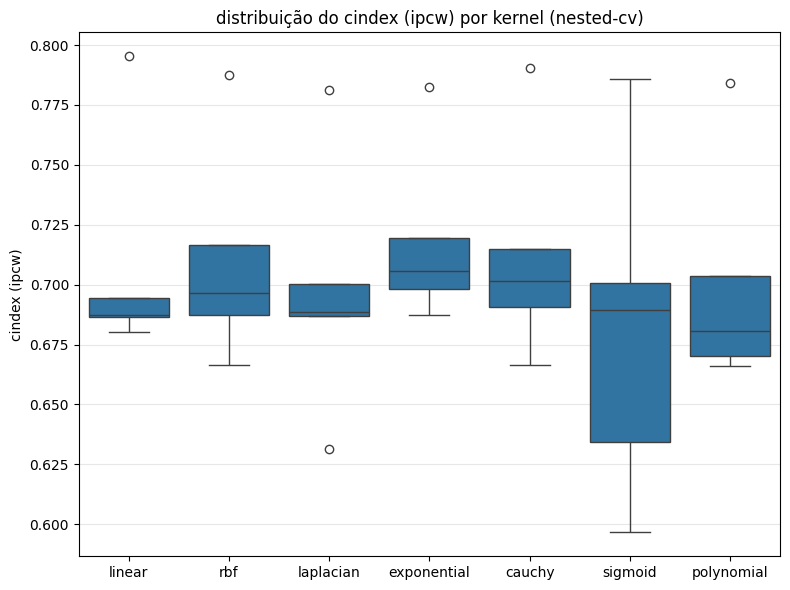

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = []

for kernel, res in all_results.items():

    for cidx in res["test_cindex"]:

        data.append({
            "kernel": kernel,
            "test_cindex": cidx
        })

df_plot_cindex = pd.DataFrame(data)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_plot_cindex,
    x="kernel",
    y="test_cindex"
)

plt.xlabel("")
plt.ylabel("cindex (ipcw)")
plt.title("distribuição do cindex (ipcw) por kernel (nested-cv)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# data = []

# for kernel, res in all_results.items():

#     for cidx in res["test_cindex"]:

#         data.append({
#             "kernel": kernel,
#             "test_cindex": cidx
#         })

# df_plot_cindex = pd.DataFrame(data)

# plt.figure(figsize=(8, 6))

# sns.violinplot(
#     data=df_plot_cindex,
#     x="kernel",
#     y="test_cindex",
#     inner="box"
# )

# plt.xlabel("")
# plt.ylabel("cindex (ipcw)")
# plt.title("distribuição do cindex (ipcw) por kernel")
# plt.grid(axis="y", alpha=0.3)

# plt.show()

In [8]:
import pandas as pd

summary = []

for kernel, results in all_results.items():
    summary.append({
        "kernel": kernel,
        "mean_ibs": results["mean_ibs"],
        "std_ibs": results["std_ibs"]
    })

df_summary = (
    pd.DataFrame(summary)
    .sort_values("mean_ibs")
    .reset_index(drop=True)
)

print(df_summary.T)

KeyError: 'mean_ibs'

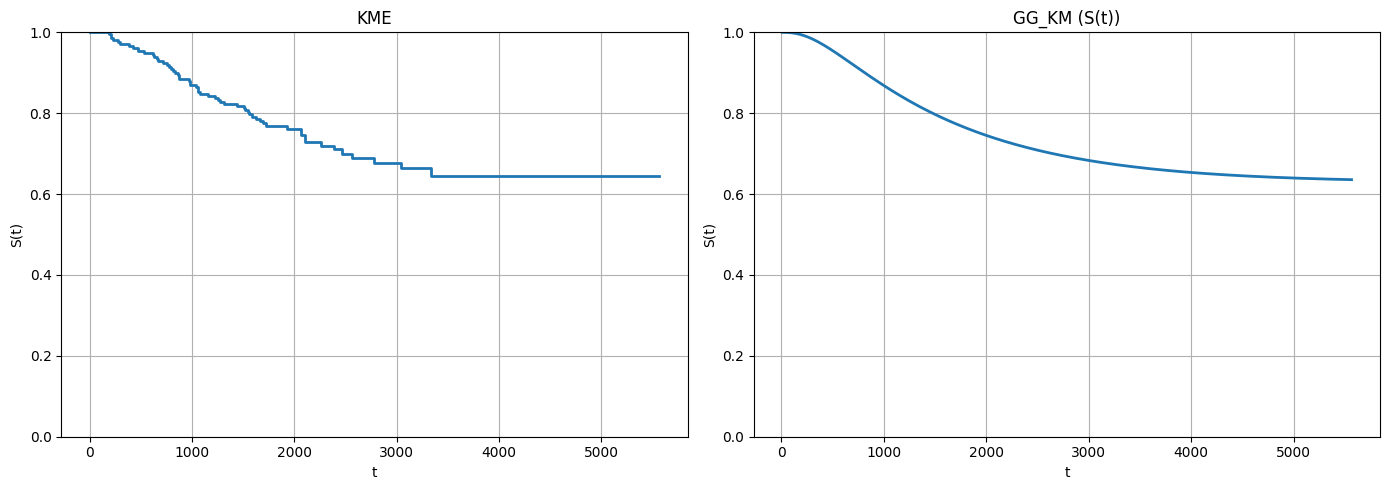

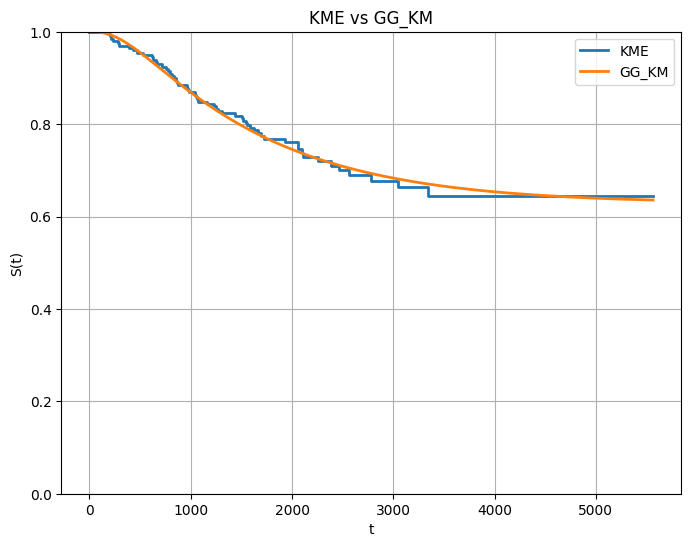

In [9]:
melanoma = (
    pd.read_csv("../data/melanoma.csv")
    .assign(status=lambda x: (x.status == 1).astype(int))
    .fillna(0)
)

y = melanoma[["time", "status"]]

X_raw = melanoma.drop(columns=y.columns.tolist()).to_numpy()

t = y["time"].to_numpy().astype(float)
delta = y["status"].to_numpy().astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

model = GG_KM(
    kernel="cauchy",
    lambda_reg=0.009163741808778781,
    gamma=0.0015339162591163618,
    degree=5,
    coef0=0.8526206184364576
)

model.fit(X_scaled, t, delta)


km_t, km_s = kaplan_meier(t, delta)


t_grid = np.linspace(
    np.min(t),
    np.max(t),
    300
)

S_pred = model.predict_survival(
    X_scaled,
    t_grid
)

S_mean = S_pred.mean(axis=0)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


axes[0].step(
    km_t,
    km_s,
    where="post",
    linewidth=2
)

axes[0].set_ylim(0,1)
axes[0].set_title("KME")
axes[0].set_xlabel("t")
axes[0].set_ylabel("S(t)")
axes[0].grid(True)

axes[1].plot(
    t_grid,
    S_mean,
    linewidth=2
)
axes[1].set_ylim(0,1)

axes[1].set_title("GG_KM (S(t))")
axes[1].set_xlabel("t")
axes[1].set_ylabel("S(t)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.step(
    km_t,
    km_s,
    where="post",
    linewidth=2,
    label="KME"
)

plt.plot(
    t_grid,
    S_mean,
    linewidth=2,
    label="GG_KM"
)

plt.ylim(0, 1)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("KME vs GG_KM")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
alpha = model.alpha_
K = model.K_

influence = np.abs(alpha) * np.sqrt(np.diag(K))

threshold = np.quantile(influence, 0.99)

outliers = influence > threshold

print(f"Number of outliers: {outliers.sum()}")

Number of outliers: 3


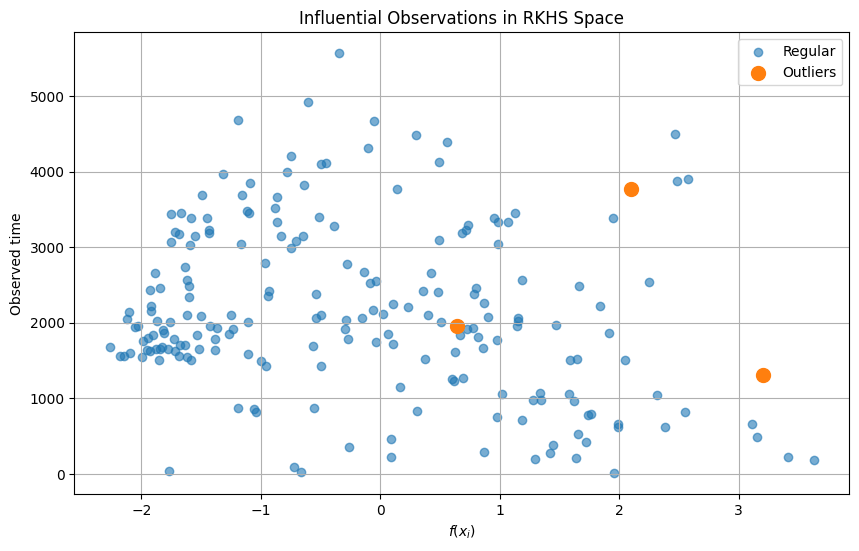

In [12]:
f_hat = model.K_ @ model.alpha_

plt.figure(figsize=(10, 6))

plt.scatter(
    f_hat[~outliers],
    t[~outliers],
    alpha=0.6,
    label="Regular"
)

plt.scatter(
    f_hat[outliers],
    t[outliers],
    s=100,
    label="Outliers"
)

plt.xlabel(r"$f(x_i)$")
plt.ylabel("Observed time")
plt.title("Influential Observations in RKHS Space")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
def pi_method(x1, x2, method):
    if method == 1:
        eta = 0.3 - 5*x1 - 3*x2
        return np.exp(eta) / (1 + np.exp(eta))

    elif method == 2:
        eta = 0.3 + 5*(x1**2) - 3*(x2**2)
        return np.exp(eta) / (1 + np.exp(eta))

    elif method == 3:
        eta = 0.3 - 5*np.cos(x1) - 3*np.sin(x2)
        return np.exp(-np.exp(eta))

    else:
        raise ValueError("method must be 1, 2, or 3")


def weibull_inverse(u, alpha, beta1, beta2, z1, z2):
    linpred = beta1*z1 + beta2*z2
    return ((-np.log(u)) / np.exp(linpred))**(1/alpha)


def simulate_pcm(n=300, method=1,
                 alpha=2, beta1=1, beta2=0.5,
                 censor_rate=0.2, seed=None):

    if seed is not None:
        np.random.seed(seed)

    x1 = np.random.normal(size=n)
    x2 = np.random.normal(size=n)

    z1 = x1.copy()
    z2 = x2.copy()

    pi_x = pi_method(x1, x2, method)

    t = np.zeros(n)
    delta = np.zeros(n, dtype=int)
    cured = np.zeros(n, dtype=int)

    for i in range(n):

        U = np.random.uniform()
        C = np.random.exponential(scale=1/censor_rate)

        if U <= (1 - pi_x[i]):
            t[i] = C
            delta[i] = 0
            cured[i] = 1

        else:
            U1 = np.random.uniform(1 - pi_x[i], 1)

            v = np.log(U1) / np.log(1 - pi_x[i])

            y = weibull_inverse(
                u=v,
                alpha=alpha,
                beta1=beta1,
                beta2=beta2,
                z1=z1[i],
                z2=z2[i]
            )

            t[i] = min(y, C)

            if y <= C:
                delta[i] = 1
            else:
                delta[i] = 0

    df = pd.DataFrame({
        "time": t,
        "event": delta,
        "x1": x1,
        "x2": x2,
        "z1": z1,
        "z2": z2,
        "pi_x": pi_x,
        "cured": cured
    })

    return df


df = simulate_pcm(
    n=600,
    method=3,
    alpha=2,
    beta1=1,
    beta2=0.5,
    seed=42
)

train_df, test_df = train_test_split(
    df,
    test_size=1/3,
    random_state=42
)

print(df.head())

print("\nCure fraction:", df["cured"].mean())
print("Censoring proportion:", 1 - df["event"].mean())
print("Events:", df["event"].sum())

       time  event        x1        x2        z1        z2      pi_x  cured
0  1.417218      1  0.496714  0.756989  0.496714  0.756989  0.997881      0
1  2.354406      1 -0.138264 -0.922165 -0.138264 -0.922165  0.901055      0
2  0.920206      1  0.647689  0.869606  0.647689  0.869606  0.997473      0
3  0.611199      1  1.523030  1.355638  1.523030  1.355638  0.944855      0
4  1.351638      0 -0.234153  0.413435 -0.234153  0.413435  0.996881      0

Cure fraction: 0.22833333333333333
Censoring proportion: 0.42500000000000004
Events: 345


In [14]:
# kernels = [
#     "linear",
#     "rbf",
#     "laplacian",
#     "exponential",
#     "cauchy",
#     "sigmoid",
#     "polynomial",
# ]

# sample_sizes = [300, 600]
# methods = [1, 2, 3]

# experiment_results = {}

# for n in sample_sizes:

#     experiment_results[n] = {}

#     for method in methods:

#         print("\n")
#         print("=" * 100)
#         print(f"SIMULATION SETTING → n={n} | method={method}")
#         print("=" * 100)

#         df = simulate_pcm(
#             n=n,
#             method=method,
#             alpha=2,
#             beta1=1,
#             beta2=0.5,
#             seed=42
#         )

#         X_raw = df[["x1", "x2"]].to_numpy()

#         t = df["time"].to_numpy().astype(float)
#         delta = df["event"].to_numpy().astype(float)

#         experiment_results[n][method] = {}

#         for kernel in kernels:

#             print("\n")
#             print("-" * 80)
#             print(f"Kernel: {kernel}")
#             print("-" * 80)

#             results = cross_validate_gg_km(
#                 X=X_raw,
#                 t=t,
#                 delta=delta,
#                 kernel=kernel,
#                 n_outer_splits=5,
#                 n_inner_splits=4,
#                 n_trials=20,
#                 t_grid_points=50,
#                 random_state=42,
#             )

#             experiment_results[n][method][kernel] = results

In [7]:
def cross_validate_pcm(
    n,
    method,
    kernel="rbf",
    n_outer_splits=5,
    n_inner_splits=4,
    n_trials=20,
    t_grid_points=50,
    random_state=42,
):

    df = simulate_pcm(
        n=n,
        method=method,
        seed=random_state
    )

    X = df[["x1", "x2"]].to_numpy()
    t = df["time"].to_numpy()
    delta = df["event"].to_numpy()

    p_cure_true = 1 - df["pi_x"].to_numpy()

    outer_cv = KFold(
        n_splits=n_outer_splits,
        shuffle=True,
        random_state=random_state
    )

    all_test_ibs = []
    all_test_cindex = []

    all_bias = []
    all_mse = []

    all_best_params = []

    print(f"\n{'='*80}")
    print(f"n={n} | Method={method} | Kernel={kernel}")
    print(f"{'='*80}")

    for fold_idx, (train_idx, test_idx) in enumerate(
        outer_cv.split(X)
    ):

        print(
            f"Outer fold {fold_idx + 1}/{n_outer_splits}"
        )

        X_outer_train, X_test = (
            X[train_idx],
            X[test_idx]
        )

        t_outer_train, t_test = (
            t[train_idx],
            t[test_idx]
        )

        d_outer_train, d_test = (
            delta[train_idx],
            delta[test_idx]
        )

        p_cure_test_true = (
            p_cure_true[test_idx]
        )

        t_grid = np.linspace(
            np.percentile(
                t_outer_train,
                5
            ),
            np.percentile(
                t_outer_train,
                95
            ),
            t_grid_points
        )

        inner_cv = KFold(
            n_splits=n_inner_splits,
            shuffle=True,
            random_state=random_state
        )

        def objective(trial):

            params = {
                "lambda_reg": trial.suggest_float(
                    "lambda_reg",
                    1e-5,
                    1.0,
                    log=True
                )
            }

            if kernel != "linear":

                params["gamma"] = (
                    trial.suggest_float(
                        "gamma",
                        1e-3,
                        10.0,
                        log=True
                    )
                )

            if kernel == "polynomial":

                params["degree"] = (
                    trial.suggest_int(
                        "degree",
                        2,
                        6
                    )
                )

                params["coef0"] = (
                    trial.suggest_float(
                        "coef0",
                        0.0,
                        5.0
                    )
                )

            if kernel == "sigmoid":

                params["coef0"] = (
                    trial.suggest_float(
                        "coef0",
                        -5.0,
                        5.0
                    )
                )

            val_scores = []

            for tr_idx, val_idx in inner_cv.split(
                X_outer_train
            ):

                X_tr = X_outer_train[tr_idx]
                X_val = X_outer_train[val_idx]

                t_tr = t_outer_train[tr_idx]
                t_val = t_outer_train[val_idx]

                d_tr = d_outer_train[tr_idx]
                d_val = d_outer_train[val_idx]

                scaler = StandardScaler()

                X_tr_s = scaler.fit_transform(
                    X_tr
                )

                X_val_s = scaler.transform(
                    X_val
                )

                t_grid_inner = np.linspace(
                    np.percentile(
                        t_tr,
                        5
                    ),
                    np.percentile(
                        t_tr,
                        95
                    ),
                    t_grid_points
                )

                try:

                    model = GG_KM(
                        kernel=kernel,
                        **params
                    )

                    model.fit(
                        X_tr_s,
                        t_tr,
                        d_tr
                    )

                    S_pred = (
                        model.predict_survival(
                            X_val_s,
                            t_grid_inner
                        )
                    )

                    ibs = integrated_brier_score(
                        S_pred,
                        t_val,
                        d_val,
                        t_tr,
                        d_tr,
                        t_grid_inner
                    )

                    val_scores.append(
                        ibs
                    )

                except Exception:
                    return 1.0

            return float(
                np.mean(val_scores)
            )

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(
                seed=random_state
            )
        )

        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=False
        )

        best_params = study.best_params

        all_best_params.append(
            best_params
        )

        scaler = StandardScaler()

        X_train_s = scaler.fit_transform(
            X_outer_train
        )

        X_test_s = scaler.transform(
            X_test
        )

        final_model = GG_KM(
            kernel=kernel,
            **best_params
        )

        final_model.fit(
            X_train_s,
            t_outer_train,
            d_outer_train
        )

        S_test = (
            final_model.predict_survival(
                X_test_s,
                t_grid
            )
        )

        # -------------------------
        # IBS
        # -------------------------
        test_ibs = integrated_brier_score(
            S_test,
            t_test,
            d_test,
            t_outer_train,
            d_outer_train,
            t_grid
        )

        all_test_ibs.append(
            test_ibs
        )

        # -------------------------
        # Uno IPCW C-index
        # -------------------------
        test_cindex = uno_c_index_rmst(
            S_pred=S_test,
            t_eval=t_test,
            delta_eval=d_test,
            t_train=t_outer_train,
            delta_train=d_outer_train,
            t_grid=t_grid,
            tau=t_grid[-1]
        )

        all_test_cindex.append(
            test_cindex
        )

        # -------------------------
        # Cure probability metrics
        # -------------------------
        p_cure_hat = (
            final_model.predict_cure_probability(
                X_test_s
            )
        )

        fold_bias = np.mean(
            p_cure_hat
            - p_cure_test_true
        )

        fold_mse = np.mean(
            (
                p_cure_hat
                - p_cure_test_true
            ) ** 2
        )

        all_bias.append(
            fold_bias
        )

        all_mse.append(
            fold_mse
        )

        print(
            f"IBS={test_ibs:.4f} | "
            f"C-index={test_cindex:.4f} | "
            f"Bias={fold_bias:.4f} | "
            f"MSE={fold_mse:.4f}"
        )

    return {

        "test_ibs": all_test_ibs,

        "mean_ibs": float(
            np.mean(all_test_ibs)
        ),

        "std_ibs": float(
            np.std(all_test_ibs)
        ),

        "test_cindex": all_test_cindex,

        "mean_cindex": float(
            np.nanmean(
                all_test_cindex
            )
        ),

        "std_cindex": float(
            np.nanstd(
                all_test_cindex
            )
        ),

        "mean_bias": float(
            np.mean(all_bias)
        ),

        "std_bias": float(
            np.std(all_bias)
        ),

        "mean_mse": float(
            np.mean(all_mse)
        ),

        "std_mse": float(
            np.std(all_mse)
        ),

        "best_params": all_best_params
    }

# def cross_validate_pcm(
#     n,
#     method,
#     kernel="rbf",
#     n_outer_splits=5,
#     n_inner_splits=4,
#     n_trials=20,
#     t_grid_points=50,
#     random_state=42,
# ):

#     df = simulate_pcm(
#         n=n,
#         method=method,
#         seed=random_state
#     )

#     X = df[["x1", "x2"]].to_numpy()
#     t = df["time"].to_numpy()
#     delta = df["event"].to_numpy()

#     p_cure_true = 1 - df["pi_x"].to_numpy()

#     outer_cv = KFold(
#         n_splits=n_outer_splits,
#         shuffle=True,
#         random_state=random_state
#     )

#     all_test_ibs = []
#     all_bias = []
#     all_mse = []
#     all_best_params = []

#     print(f"\n{'='*80}")
#     print(f"n={n} | Method={method} | Kernel={kernel}")
#     print(f"{'='*80}")

#     for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X)):

#         print(f"Outer fold {fold_idx + 1}/{n_outer_splits}")

#         X_outer_train, X_test = X[train_idx], X[test_idx]
#         t_outer_train, t_test = t[train_idx], t[test_idx]
#         d_outer_train, d_test = delta[train_idx], delta[test_idx]

#         p_cure_test_true = p_cure_true[test_idx]

#         t_grid = np.linspace(
#             np.percentile(t_outer_train, 5),
#             np.percentile(t_outer_train, 95),
#             t_grid_points
#         )

#         inner_cv = KFold(
#             n_splits=n_inner_splits,
#             shuffle=True,
#             random_state=random_state
#         )

#         def objective(trial):

#             params = {
#                 "lambda_reg": trial.suggest_float(
#                     "lambda_reg",
#                     1e-5,
#                     1.0,
#                     log=True
#                 )
#             }

#             if kernel != "linear":
#                 params["gamma"] = trial.suggest_float(
#                     "gamma",
#                     1e-3,
#                     10.0,
#                     log=True
#                 )

#             if kernel == "polynomial":
#                 params["degree"] = trial.suggest_int(
#                     "degree",
#                     2,
#                     6
#                 )

#                 params["coef0"] = trial.suggest_float(
#                     "coef0",
#                     0.0,
#                     5.0
#                 )

#             if kernel == "sigmoid":
#                 params["coef0"] = trial.suggest_float(
#                     "coef0",
#                     -5.0,
#                     5.0
#                 )

#             val_scores = []

#             for tr_idx, val_idx in inner_cv.split(X_outer_train):

#                 X_tr = X_outer_train[tr_idx]
#                 X_val = X_outer_train[val_idx]

#                 t_tr = t_outer_train[tr_idx]
#                 t_val = t_outer_train[val_idx]

#                 d_tr = d_outer_train[tr_idx]
#                 d_val = d_outer_train[val_idx]

#                 scaler = StandardScaler()

#                 X_tr_s = scaler.fit_transform(X_tr)
#                 X_val_s = scaler.transform(X_val)

#                 t_grid_inner = np.linspace(
#                     np.percentile(t_tr, 5),
#                     np.percentile(t_tr, 95),
#                     t_grid_points
#                 )

#                 try:
#                     model = GG_KM(
#                         kernel=kernel,
#                         **params
#                     )

#                     model.fit(X_tr_s, t_tr, d_tr)

#                     S_pred = model.predict_survival(
#                         X_val_s,
#                         t_grid_inner
#                     )

#                     ibs = integrated_brier_score(
#                         S_pred,
#                         t_val,
#                         d_val,
#                         t_tr,
#                         d_tr,
#                         t_grid_inner
#                     )

#                     val_scores.append(ibs)

#                 except Exception:
#                     return 1.0

#             return float(np.mean(val_scores))

#         study = optuna.create_study(
#             direction="minimize",
#             sampler=optuna.samplers.TPESampler(
#                 seed=random_state
#             )
#         )

#         study.optimize(
#             objective,
#             n_trials=n_trials,
#             show_progress_bar=False
#         )

#         best_params = study.best_params
#         all_best_params.append(best_params)

#         scaler = StandardScaler()

#         X_train_s = scaler.fit_transform(X_outer_train)
#         X_test_s = scaler.transform(X_test)

#         final_model = GG_KM(
#             kernel=kernel,
#             **best_params
#         )

#         final_model.fit(
#             X_train_s,
#             t_outer_train,
#             d_outer_train
#         )

#         S_test = final_model.predict_survival(
#             X_test_s,
#             t_grid
#         )

#         test_ibs = integrated_brier_score(
#             S_test,
#             t_test,
#             d_test,
#             t_outer_train,
#             d_outer_train,
#             t_grid
#         )

#         all_test_ibs.append(test_ibs)

#         p_cure_hat = final_model.predict_cure_probability(
#             X_test_s
#         )

#         fold_bias = np.mean(
#             p_cure_hat - p_cure_test_true
#         )

#         fold_mse = np.mean(
#             (p_cure_hat - p_cure_test_true) ** 2
#         )

#         all_bias.append(fold_bias)
#         all_mse.append(fold_mse)

#         print(
#             f"IBS={test_ibs:.4f} | "
#             f"Bias={fold_bias:.4f} | "
#             f"MSE={fold_mse:.4f}"
#         )

#     return {
#         "test_ibs": all_test_ibs,
#         "mean_ibs": float(np.mean(all_test_ibs)),
#         "std_ibs": float(np.std(all_test_ibs)),
#         "mean_bias": float(np.mean(all_bias)),
#         "std_bias": float(np.std(all_bias)),
#         "mean_mse": float(np.mean(all_mse)),
#         "std_mse": float(np.std(all_mse)),
#         "best_params": all_best_params
#     }

In [8]:
kernels = [
    "linear",
    "rbf",
    "laplacian",
    "exponential",
    "cauchy",
    "sigmoid",
    "polynomial",
]

sample_sizes = [300, 600]
methods = [1, 2, 3]

experiment_results = {}

for n in sample_sizes:

    experiment_results[n] = {}

    for method in methods:

        print("\n")
        print("=" * 100)
        print(f"SIMULATION SETTING → n={n} | method={method}")
        print("=" * 100)

        experiment_results[n][method] = {}

        for kernel in kernels:

            print("\n")
            print("-" * 80)
            print(f"Kernel: {kernel}")
            print("-" * 80)

            results = cross_validate_pcm(
                n=n,
                method=method,
                kernel=kernel,
                n_outer_splits=5,
                n_inner_splits=4,
                n_trials=20,
                t_grid_points=50,
                random_state=42,
            )

            experiment_results[n][method][kernel] = results



SIMULATION SETTING → n=300 | method=1


--------------------------------------------------------------------------------
Kernel: linear
--------------------------------------------------------------------------------

n=300 | Method=1 | Kernel=linear
Outer fold 1/5
IBS=0.1778 | C-index=0.6789 | Bias=-0.0900 | MSE=0.0726
Outer fold 2/5
IBS=0.0998 | C-index=0.6981 | Bias=-0.0710 | MSE=0.0633
Outer fold 3/5
IBS=0.1509 | C-index=0.7081 | Bias=-0.0743 | MSE=0.0645
Outer fold 4/5


non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

IBS=0.1527 | C-index=0.5942 | Bias=-0.1249 | MSE=0.0705
Outer fold 5/5
IBS=0.1875 | C-index=0.8237 | Bias=-0.1525 | MSE=0.0968


--------------------------------------------------------------------------------
Kernel: rbf
--------------------------------------------------------------------------------

n=300 | Method=1 | Kernel=rbf
Outer fold 1/5


[W 2026-07-17 12:12:20,455] Trial 15 failed with parameters: {'lambda_reg': 0.023148853662559914, 'gamma': 0.04255007010130248} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/cowvin/Documents/master_pipges/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_56336/3484837230.py", line 181, in objective
    model.fit(
  File "/home/cowvin/Documents/master_pipges/topicos_pesquisa_I/aplicacao_relatorio_2/km_gg.py", line 261, in fit
    result_alpha = minimize(
                   ^^^^^^^^^
  File "/home/cowvin/Documents/master_pipges/.venv/lib/python3.12/site-packages/scipy/optimize/_minimize.py", line 784, in minimize
    res = _minimize_lbfgsb(fun, x0, args, jac, bounds,
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cowvin/Documents/master_pipges/.venv/lib/python3.12/site-packages/scipy/o

KeyboardInterrupt: 

In [ ]:
# pd.DataFrame(experiment_results).to_csv("experiment_results_em_bn.csv",index=False)

In [19]:
summary_rows = []

for n in experiment_results:
    for method in experiment_results[n]:

        # kernel_results = eval(experiment_results.loc[method, n])
        kernel_results = experiment_results[n][method]

        best_kernel = min(
            kernel_results.keys(),
            key=lambda k: kernel_results[k]["mean_ibs"]
        )

        best_metrics = kernel_results[best_kernel]

        summary_rows.append({
            "sample_size": n,
            "method": method,
            "best_kernel": best_kernel,
            "mean_ibs": best_metrics["mean_ibs"],
            "std_ibs": best_metrics["std_ibs"],
            "mean_bias": best_metrics["mean_bias"],
            "std_bias": best_metrics["std_bias"],
            "mean_mse": best_metrics["mean_mse"],
            "std_mse": best_metrics["std_mse"]
        })

summary_table = pd.DataFrame(summary_rows)
# for n in experiment_results.columns:
#     for method in experiment_results.index:

#         kernel_results = eval(experiment_results.loc[method, n])

#         best_kernel = min(
#             kernel_results.keys(),
#             key=lambda k: kernel_results[k]["mean_ibs"]
#         )

#         best_metrics = kernel_results[best_kernel]

#         summary_rows.append({
#             "sample_size": n,
#             "method": method,
#             "best_kernel": best_kernel,
#             "mean_ibs": best_metrics["mean_ibs"],
#             "std_ibs": best_metrics["std_ibs"],
#             "mean_bias": best_metrics["mean_bias"],
#             "std_bias": best_metrics["std_bias"],
#             "mean_mse": best_metrics["mean_mse"],
#             "std_mse": best_metrics["std_mse"]
#         })

# summary_table = pd.DataFrame(summary_rows)

In [20]:
summary_table

,sample_size,method,best_kernel,mean_ibs,std_ibs,mean_bias,std_bias,mean_mse,std_mse
0,300,1,exponential,0.122025,0.039929,-0.044292,0.043507,0.029244,0.006987
1,300,2,cauchy,0.152794,0.023708,0.053932,0.039657,0.070618,0.013096
2,300,3,exponential,0.122617,0.017758,-0.003888,0.013077,0.019667,0.009651
3,600,1,sigmoid,0.100775,0.018062,0.011809,0.013125,0.030010,0.010256
4,600,2,exponential,0.142960,0.041257,-0.004596,0.020471,0.029693,0.008062
5,600,3,cauchy,0.085603,0.028116,0.005180,0.021620,0.021283,0.008504


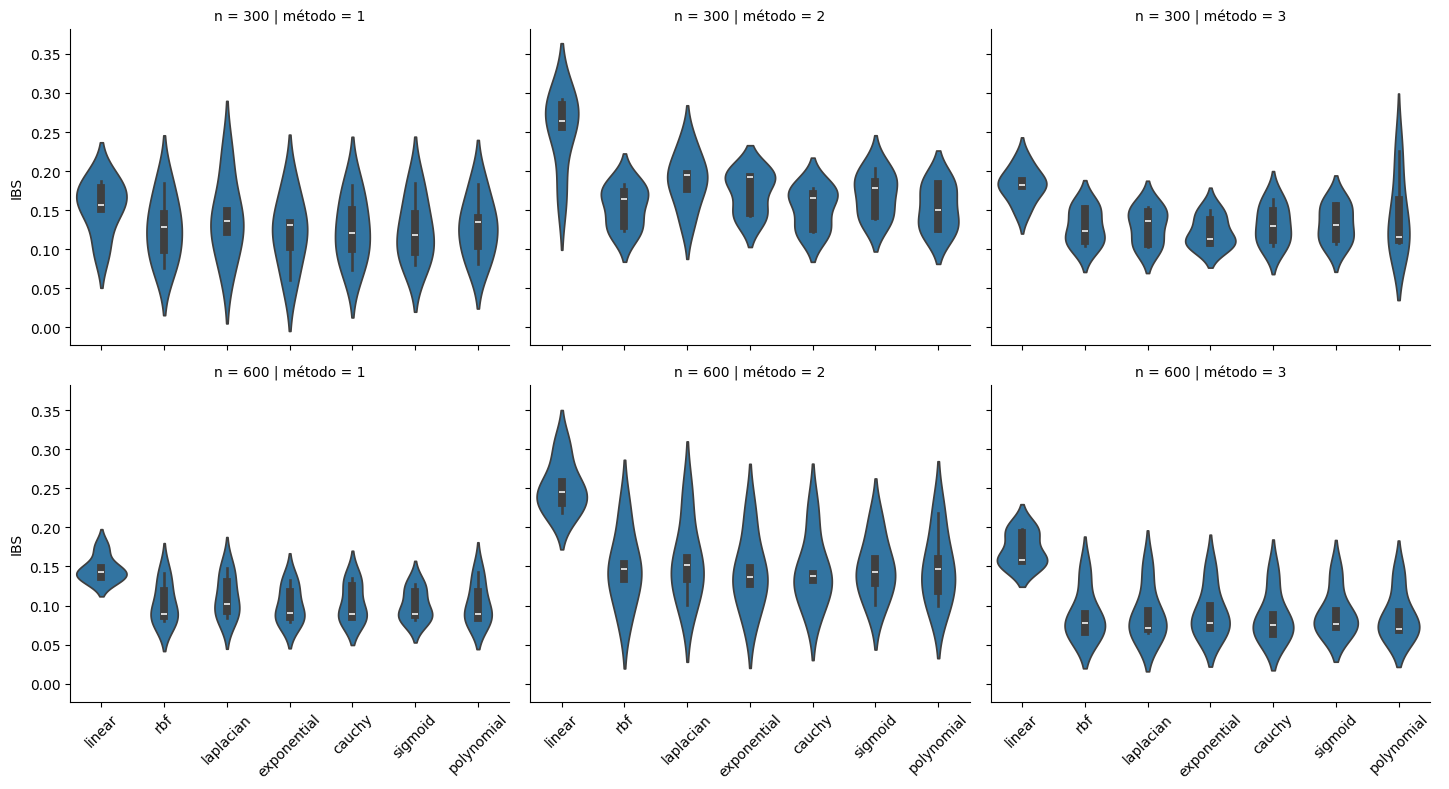

In [21]:
data = []

for sample_size, methods in experiment_results.items():
    for method_id, kernels in methods.items():
        if isinstance(kernels, str):
            kernels = eval(kernels)

        for kernel_name, results in kernels.items():
            for ibs in results["test_ibs"]:
                data.append({
                    "n": sample_size,
                    "método": method_id,
                    "kernel": kernel_name,
                    "test_ibs": float(ibs)
                })

df_plot = pd.DataFrame(data)

df_plot["kernel"] = df_plot["kernel"].astype("category")

kernel_order = df_plot["kernel"].unique()

g = sns.catplot(
    data=df_plot,
    x="kernel",
    y="test_ibs",
    row="n",
    col="método",
    kind="violin",
    inner="box",
    order=kernel_order,
    height=4,
    aspect=1.2
)

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("IBS")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [52]:
melanoma_results_em = pd.read_csv("melanoma_results_em_bn.csv")

In [53]:
melanoma_results_em.T.sort_values(by=1).drop(columns=[0,3])

,1,2
exponential,0.15444498462678774,0.022286747882238982
cauchy,0.15482395908916444,0.02501227512625738
laplacian,0.15594158290502616,0.02393713781824356
rbf,0.15718243426492853,0.02447305366788488
linear,0.15734622472722185,0.02459355403193075
polynomial,0.159198573373114,0.017755817143101135
sigmoid,0.15984119650026646,0.026405285746334915


In [46]:
melanoma_results_em

{'linear': {0: '[np.float64(0.11289903800003545), np.float64(0.15089858802780695), np.float64(0.16432627982039738), np.float64(0.19794727583921376), np.float64(0.1294305043601974)]',
  1: '0.1511003372095302',
  2: '0.029320719079391565',
  3: "[{'lambda_reg': 0.974217634211552}, {'lambda_reg': 0.566984951147885}, {'lambda_reg': 0.9724175504919988}, {'lambda_reg': 0.974217634211552}, {'lambda_reg': 0.974217634211552}]"},
 'rbf': {0: '[np.float64(0.11904767646911456), np.float64(0.15116296750141336), np.float64(0.17425722188140783), np.float64(0.2000639065383416), np.float64(0.13349800298368825)]',
  1: '0.1556059550747931',
  2: '0.028876941045328786',
  3: "[{'lambda_reg': 0.8192602279031006, 'gamma': 0.023739423955292542}, {'lambda_reg': 0.567005066101662, 'gamma': 0.026810157533840164}, {'lambda_reg': 0.3708059888336652, 'gamma': 0.01324683205408713}, {'lambda_reg': 0.1452824663751603, 'gamma': 0.0070689749506246055}, {'lambda_reg': 0.8192602279031006, 'gamma': 0.023739423955292542}

In [42]:
for n in [300, 600]:
    for method in [1, 2, 3]:

        kernel_results = eval(experiment_results_bn[str(n)][method - 1])
        # kernel_results = experiment_results[n][method]

        best_kernel = min(
            kernel_results.keys(),
            key=lambda k: kernel_results[k]["mean_ibs"]
        )

        best_params = kernel_results[best_kernel]["best_params"][0]

        print(f"\nn={n} | method={method}")
        print(f"Best kernel: {best_kernel}")
        print(f"Best IBS: {kernel_results[best_kernel]['mean_ibs']:.4f}")
        print(f"mean bias: {kernel_results[best_kernel]['mean_bias']:.4f}")
        print(f"mean mse: {kernel_results[best_kernel]['mean_mse']:.4f}")

# experiment_results_poisson


n=300 | method=1
Best kernel: exponential
Best IBS: 0.1220
mean bias: -0.0443
mean mse: 0.0292

n=300 | method=2
Best kernel: cauchy
Best IBS: 0.1528
mean bias: 0.0539
mean mse: 0.0706

n=300 | method=3
Best kernel: exponential
Best IBS: 0.1226
mean bias: -0.0039
mean mse: 0.0197

n=600 | method=1
Best kernel: sigmoid
Best IBS: 0.1008
mean bias: 0.0118
mean mse: 0.0300

n=600 | method=2
Best kernel: exponential
Best IBS: 0.1430
mean bias: -0.0046
mean mse: 0.0297

n=600 | method=3
Best kernel: cauchy
Best IBS: 0.0856
mean bias: 0.0052
mean mse: 0.0213


In [ ]:
# experiment_results = pd.read_csv("experiment_results_em.csv")
# experiment_results.index = range(1, 4)

def plot_best_survival_curves(
    experiment_results,
    sample_sizes,
    methods,
    t_grid_points=100,
    random_state=42,
):

    n_rows = len(sample_sizes)
    n_cols = len(methods)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
        squeeze=False
    )

    for i, n in enumerate(sample_sizes):
        for j, method in enumerate(methods):

            ax = axes[i, j]

            # kernel_results = eval(experiment_results[str(n)][method])
            kernel_results = experiment_results[n][method]

            best_kernel = min(
                kernel_results.keys(),
                key=lambda k: kernel_results[k]["mean_ibs"]
            )

            best_params = kernel_results[best_kernel]["best_params"][0]

            print(f"\nn={n} | method={method}")
            print(f"Best kernel: {best_kernel}")
            print(f"Best IBS: {kernel_results[best_kernel]['mean_ibs']:.4f}")

            df = simulate_pcm(
                n=n,
                method=method,
                alpha=2,
                beta1=1,
                beta2=0.5,
                seed=random_state
            )

            X = df[["x1", "x2"]].to_numpy()
            t = df["time"].to_numpy().astype(float)
            delta = df["event"].to_numpy().astype(float)

            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            model = GG_KM(
                kernel=best_kernel,
                **best_params
            )

            model.fit(X_scaled, t, delta)

            t_grid = np.linspace(
                np.min(t),
                np.max(t),
                t_grid_points
            )

            S_pred = model.predict_survival(
                X_scaled,
                t_grid
            )

            S_mean = S_pred.mean(axis=0)

            kmf = KaplanMeierFitter()
            kmf.fit(
                durations=t,
                event_observed=delta
            )

            kmf.plot_survival_function(
                ax=ax,
                ci_show=False
            )

            ax.plot(
                t_grid,
                S_mean,
                linewidth=2,
                label=f"GG_KM ({best_kernel})"
            )

            ax.set_title(
                f"n={n} | método={method}"
            )

            ax.set_xlabel("t")
            ax.set_ylabel("S(t)")
            ax.set_ylim(0, 1)
            ax.grid(True)
            ax.legend()

    plt.tight_layout()
    plt.show()

# def plot_best_survival_curves(
#     experiment_results,
#     sample_sizes,
#     methods,
#     t_grid_points=100,
#     random_state=42,
# ):

#     for n in sample_sizes:
#         for method in methods:

#             # kernel_results = eval(experiment_results[n][method])
#             kernel_results = experiment_results[n][method]

#             best_kernel = min(
#                 kernel_results.keys(),
#                 key=lambda k: kernel_results[k]["mean_ibs"]
#             )

#             best_params = kernel_results[best_kernel]["best_params"][0]

#             print(f"\nn={n} | method={method}")
#             print(f"Best kernel: {best_kernel}")
#             print(f"Best IBS: {kernel_results[best_kernel]['mean_ibs']:.4f}")

#             df = simulate_pcm(
#                 n=n,
#                 method=method,
#                 alpha=2,
#                 beta1=1,
#                 beta2=0.5,
#                 seed=random_state
#             )

#             X = df[["x1", "x2"]].to_numpy()
#             t = df["time"].to_numpy().astype(float)
#             delta = df["event"].to_numpy().astype(float)

#             scaler = StandardScaler()
#             X_scaled = scaler.fit_transform(X)

#             model = GG_KM(
#                 kernel=best_kernel,
#                 **best_params
#             )

#             model.fit(X_scaled, t, delta)

#             t_grid = np.linspace(
#                 np.percentile(t, 0),
#                 np.percentile(t, 100),
#                 t_grid_points
#             )

#             S_pred = model.predict_survival(
#                 X_scaled,
#                 # t,
#                 t_grid
#             )

#             S_mean = S_pred.mean(axis=0)

#             kmf = KaplanMeierFitter()
#             kmf.fit(
#                 durations=t,
#                 event_observed=delta
#             )

#             plt.figure(figsize=(8, 6))

#             kmf.plot_survival_function()

#             plt.plot(
#                 t_grid,
#                 S_mean,
#                 linewidth=2,
#                 label=f"GG_KM ({best_kernel})"
#             )

#             plt.title(
#                 f"n={n} | método={method}"
#             )

#             plt.xlabel("t")
#             plt.ylabel("S(t)")

#             plt.ylim(0, 1)

#             plt.legend()
#             plt.grid(True)
#             plt.show()


n=300 | method=1
Best kernel: exponential
Best IBS: 0.1220

n=300 | method=2
Best kernel: cauchy
Best IBS: 0.1528

n=300 | method=3
Best kernel: exponential
Best IBS: 0.1226

n=600 | method=1
Best kernel: sigmoid
Best IBS: 0.1008

n=600 | method=2
Best kernel: exponential
Best IBS: 0.1430

n=600 | method=3
Best kernel: cauchy
Best IBS: 0.0856


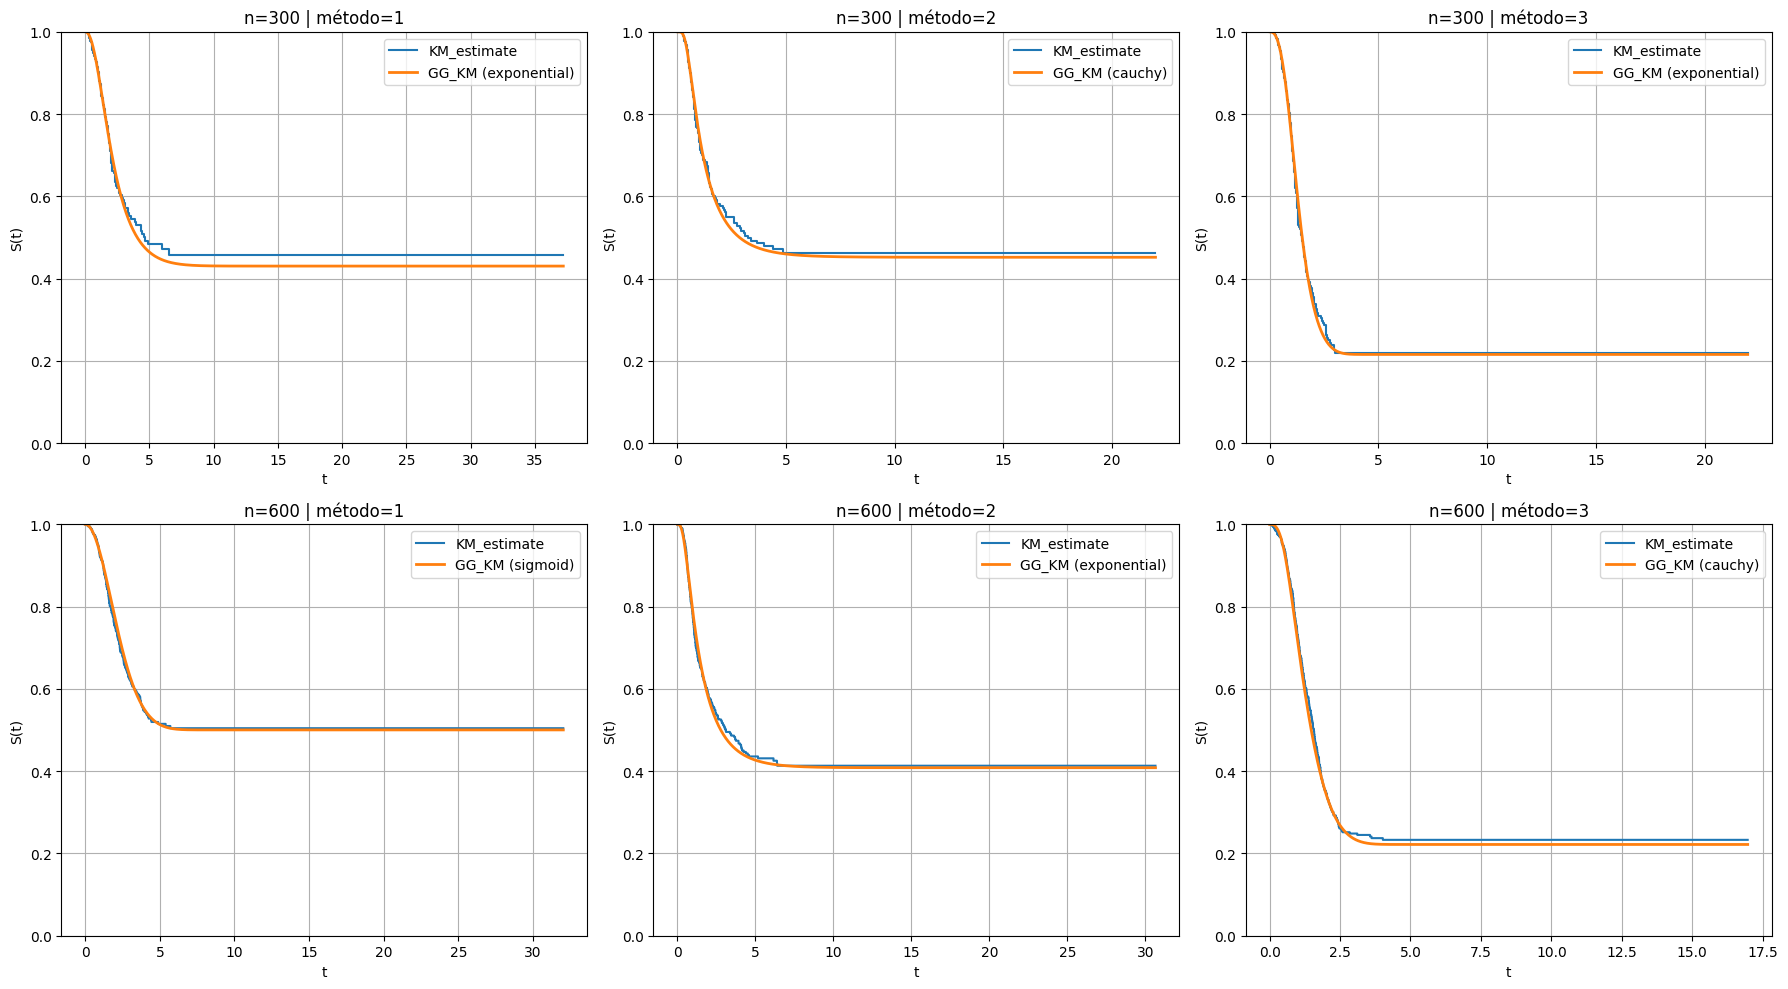

In [24]:
plot_best_survival_curves(
    experiment_results=experiment_results,
    sample_sizes=[300, 600],
    methods=[1, 2, 3],
    t_grid_points=1000
)

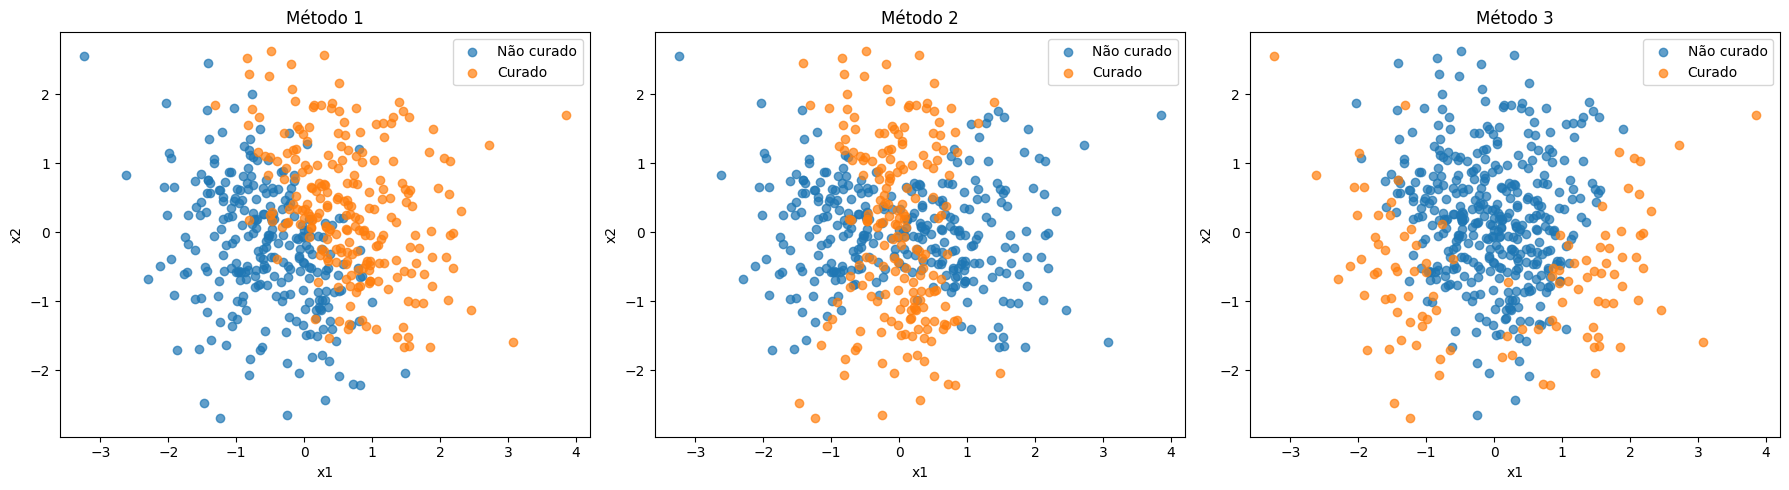

In [25]:
# plot methods for each data

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for method in [1, 2, 3]:

    df = simulate_pcm(
        n=500,
        method=method,
        seed=42
    )

    ax = axes[method - 1]

    cured = df[df["cured"] == 1]
    uncured = df[df["cured"] == 0]

    # plot uncured
    ax.scatter(
        uncured["x1"],
        uncured["x2"],
        alpha=0.7,
        label="Não curado"
    )

    # plot cured
    ax.scatter(
        cured["x1"],
        cured["x2"],
        alpha=0.7,
        label="Curado"
    )

    ax.set_title(f"Método {method}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()

plt.tight_layout()
plt.show()